Read in the movie dataset, set the index to the movie title, and inspect the first few
rows of the duration column:

In [ ]:
import pandas as pd
import numpy as np

In [56]:
movie = pd.read_csv("data\\movie.csv", index_col="movie_title")

In [37]:
movie[["duration"]].head()

,duration
movie_title,
Avatar,178.0
Pirates of the Caribbean: At World's End,169.0
Spectre,148.0
The Dark Knight Rises,164.0
Star Wars: Episode VII - The Force Awakens,NaN


Determine whether the duration of each movie is longer than two hours by using the
greater than comparison operator with the duration column:

In [39]:
movie_2_hours = movie["duration"] > 120
movie_2_hours.head(10)

movie_title
Avatar                                         True
Pirates of the Caribbean: At World's End       True
Spectre                                        True
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
John Carter                                    True
Spider-Man 3                                   True
Tangled                                       False
Avengers: Age of Ultron                        True
Harry Potter and the Half-Blood Prince         True
Name: duration, dtype: bool

We can now use this Series to determine the number of movies that are longer than
two hours:

In [40]:
movie_2_hours.sum()

1039

To find the percentage of movies in the dataset longer than two hours, use the .mean
method:

In [41]:
movie_2_hours.mean() * 100

21.13506916192026

Unfortunately, the output from above step is misleading. The duration column has a few
missing values.  The Boolean condition returns False for this. We need to drop the missing values first, then evaluate the
condition and take the mean:

In [42]:
movie["duration"].dropna().gt(120).mean() * 100

21.199755152009793

Use the .describe method to output summary statistics on the Boolean array:

In [43]:
movie_2_hours.describe()

count      4916
unique        2
top       False
freq       3877
Name: duration, dtype: object

It is possible to compare two columns from the same DataFrame to produce a Boolean Series.
For instance, we could determine the percentage of movies that have actor 1 with more
Facebook likes than actor 2. To do this, we would select both of these columns and then drop
any of the rows that had missing values for either movie. Then we would make the comparison
and calculate the mean:

In [44]:
actors = movie[["actor_1_facebook_likes", "actor_2_facebook_likes"]].dropna()

(
    actors["actor_1_facebook_likes"] > actors["actor_2_facebook_likes"]
).mean()

0.9777687130328371

## Constructing multiple Boolean conditions

In Python, Boolean expressions use the built-in logical operators and, or, and not. These
keywords do not work with Boolean indexing in pandas and are respectively replaced with
&, |, and ~. Additionally, when combining expressions, each expression must be wrapped in
parentheses, or an error will be raised (due to operator precedence).

Constructing a filter for your dataset might require combining multiple Boolean expressions
together to pull out the rows you need. In this recipe, we construct multiple Boolean
expressions before combining them to find all the movies that have an imdb_score greater
than 8, a content_rating of PG-13, and a title_year either before 2000 or after 2009.

Create a variable to hold each filter as a Boolean array:

In [45]:
criteria1 = movie.imdb_score > 8
criteria2 = movie.content_rating == "PG-13"
criteria3 = (movie.title_year < 2000) | (movie.title_year > 2009)

Combine all the filters into a single Boolean array:

In [46]:
criteria_final = criteria1 & criteria2 & criteria3
criteria_final.head()

movie_title
Avatar                                        False
Pirates of the Caribbean: At World's End      False
Spectre                                       False
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
dtype: bool

## Filtering with Boolean arrays

Both Series and DataFrame can be filtered with Boolean arrays. You can index this directly off
of the object or off of the .loc attribute.

This recipe constructs two complex filters for different rows of movies. The first filters movies
with an imdb_score greater than 8, a content_rating of PG-13, and a title_year
either before 2000 or after 2009. The second filter consists of those with an imdb_score
less than 5, a content_rating of R, and a title_year between 2000 and 2010. Finally,
we will combine these filters.

Read in the movie dataset, set the index to movie_title, and create the first set of
criteria:

In [57]:
movie = pd.read_csv("data\\movie.csv", index_col="movie_title")

In [48]:
crit_a1 = movie.imdb_score > 8
crit_a2 = movie.content_rating == "PG-13"
crit_a3 = (movie.title_year < 2000) | (movie.title_year > 2009)

final_crit_a = crit_a1 & crit_a2 & crit_a3

Create criteria for the second set of movies:

In [49]:
crit_b1 = movie.imdb_score < 5
crit_b2 = movie.content_rating == "R"
crit_b3 = (movie.title_year >= 2000) & (movie.title_year <= 2010)

final_crit_b = crit_b1 & crit_b2 & crit_b3

Combine the two sets of criteria using the pandas or operator. This yields a Boolean
array of all movies that are members of either set:

In [50]:
final_crit_all = final_crit_a | final_crit_b
final_crit_all.head()

movie_title
Avatar                                        False
Pirates of the Caribbean: At World's End      False
Spectre                                       False
The Dark Knight Rises                          True
Star Wars: Episode VII - The Force Awakens    False
dtype: bool

In [51]:
movie[final_crit_all].head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
movie_title,,,,,,,,,,,,,,,,,,,,,
The Dark Knight Rises,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
The Avengers,Color,Joss Whedon,703.0,173.0,0.0,19000.0,Robert Downey Jr.,26000.0,623279547.0,Action|Adventure|Sci-Fi,...,1722.0,English,USA,PG-13,220000000.0,2012.0,21000.0,8.1,1.85,123000
Captain America: Civil War,Color,Anthony Russo,516.0,147.0,94.0,11000.0,Scarlett Johansson,21000.0,407197282.0,Action|Adventure|Sci-Fi,...,1022.0,English,USA,PG-13,250000000.0,2016.0,19000.0,8.2,2.35,72000
Guardians of the Galaxy,Color,James Gunn,653.0,121.0,571.0,3000.0,Vin Diesel,14000.0,333130696.0,Action|Adventure|Sci-Fi,...,1097.0,English,USA,PG-13,170000000.0,2014.0,14000.0,8.1,2.35,96000
Interstellar,Color,Christopher Nolan,712.0,169.0,22000.0,6000.0,Anne Hathaway,11000.0,187991439.0,Adventure|Drama|Sci-Fi,...,2725.0,English,USA,PG-13,165000000.0,2014.0,11000.0,8.6,2.35,349000


We can also filter off of the .loc attribute:

In [52]:
movie.loc[final_crit_all].head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
movie_title,,,,,,,,,,,,,,,,,,,,,
The Dark Knight Rises,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
The Avengers,Color,Joss Whedon,703.0,173.0,0.0,19000.0,Robert Downey Jr.,26000.0,623279547.0,Action|Adventure|Sci-Fi,...,1722.0,English,USA,PG-13,220000000.0,2012.0,21000.0,8.1,1.85,123000
Captain America: Civil War,Color,Anthony Russo,516.0,147.0,94.0,11000.0,Scarlett Johansson,21000.0,407197282.0,Action|Adventure|Sci-Fi,...,1022.0,English,USA,PG-13,250000000.0,2016.0,19000.0,8.2,2.35,72000
Guardians of the Galaxy,Color,James Gunn,653.0,121.0,571.0,3000.0,Vin Diesel,14000.0,333130696.0,Action|Adventure|Sci-Fi,...,1097.0,English,USA,PG-13,170000000.0,2014.0,14000.0,8.1,2.35,96000
Interstellar,Color,Christopher Nolan,712.0,169.0,22000.0,6000.0,Anne Hathaway,11000.0,187991439.0,Adventure|Drama|Sci-Fi,...,2725.0,English,USA,PG-13,165000000.0,2014.0,11000.0,8.6,2.35,349000


In addition, we can specify columns to select with the .loc attribute:

In [53]:
cols = ["imdb_score", "content_rating", "title_year"]
movie_filtered = movie.loc[final_crit_all, cols]
movie_filtered.head(10)

,imdb_score,content_rating,title_year
movie_title,,,
The Dark Knight Rises,8.5,PG-13,2012.0
The Avengers,8.1,PG-13,2012.0
Captain America: Civil War,8.2,PG-13,2016.0
Guardians of the Galaxy,8.1,PG-13,2014.0
Interstellar,8.6,PG-13,2014.0
Inception,8.8,PG-13,2010.0
The Martian,8.1,PG-13,2015.0
Town & Country,4.4,R,2001.0
Sex and the City 2,4.3,R,2010.0


Filtering also works with the .loc attribute by simultaneously selecting
rows (using the Boolean array) and columns. This slimmed DataFrame is far easier to check
manually as to whether the logic was implemented correctly.

The .iloc attribute does not support Boolean arrays! If you pass in a Boolean Series to it,
an exception will get raised. However, it does work with NumPy arrays, so if you call the .to_
numpy() method, you can filter with it:

In [ ]:
movie.iloc[final_crit_all] # This gives error

In [ ]:
movie.iloc[final_crit_all.to_numpy()]

## Translating SQL WHERE clauses

Many pandas users will have experience of interacting with a database using Structured
Query Language (SQL). SQL is a standard to define, manipulate, and control data stored in a
database.

SQL is an important language for data scientists to know. Much of the world's data is stored
in databases that require SQL to retrieve and manipulate it SQL syntax is fairly simple and
easy to learn. There are many different SQL implementations from companies such as Oracle,
Microsoft, IBM, and more.

Within a SQL SELECT statement, the WHERE clause is very common and filters data. This
recipe will write pandas code that is equivalent to a SQL query that selects a certain subset
of the employee dataset.

Suppose we are given a task to find all the female employees who work in the police or fire
departments who have a base salary of between 80 and 120 thousand dollars.

The following SQL statement would answer this query for us:

In [ ]:
SELECT
    UNIQUE_ID,
    DEPARTMENT,
    GENDER,
    BASE_SALARY
FROM EMPLOYEE
WHERE DEPARTMENT IN ('Houston Police Department-HPD',
                    'Houston Fire Department (HFD)') 
AND GENDER = 'Female' 
AND BASE_SALARY BETWEEN 80000 AND 120000;

This recipe assumes that you have a dump of the EMPLOYEE database in a CSV file and that
you want to replicate the above query using pandas.

Read in the employee dataset as a DataFrame:

In [58]:
employee = pd.read_csv("data\\employee.csv")

Before filtering out the data, it is helpful to do some manual inspection of each of the
filtered columns to know the exact values that will be used in the filter:

In [59]:
employee.dtypes

UNIQUE_ID              int64
POSITION_TITLE        object
DEPARTMENT            object
BASE_SALARY          float64
RACE                  object
EMPLOYMENT_TYPE       object
GENDER                object
EMPLOYMENT_STATUS     object
HIRE_DATE             object
JOB_DATE              object
dtype: object

In [60]:
employee.DEPARTMENT.value_counts().head()

DEPARTMENT
Houston Police Department-HPD     638
Houston Fire Department (HFD)     384
Public Works & Engineering-PWE    343
Health & Human Services           110
Houston Airport System (HAS)      106
Name: count, dtype: int64

In [61]:
employee.GENDER.value_counts()

GENDER
Male      1397
Female     603
Name: count, dtype: int64

In [62]:
employee.BASE_SALARY.describe()

count      1886.000000
mean      55767.931601
std       21693.706679
min       24960.000000
25%       40170.000000
50%       54461.000000
75%       66614.000000
max      275000.000000
Name: BASE_SALARY, dtype: float64

Write a single statement for each of the criteria. Use the isin method to test equality
to one of many values:

In [63]:
depts = [
    "Houston Police Department-HPD",
    "Houston Fire Department (HFD)"
]
criteria_dept = employee.DEPARTMENT.isin(depts)
criteria_gender = employee.GENDER == "Female"
criteria_sal = (employee.BASE_SALARY >= 80000) & (employee.BASE_SALARY <= 120000)

Combine all the Boolean arrays:

In [64]:
criteria_final = (criteria_dept & criteria_gender & criteria_sal)

Use Boolean indexing to select only the rows that meet the final criteria:

In [65]:
select_columns = [
    "UNIQUE_ID",
    "DEPARTMENT",
    "GENDER",
    "BASE_SALARY"
]

In [66]:
employee.loc[criteria_final, select_columns].head()

,UNIQUE_ID,DEPARTMENT,GENDER,BASE_SALARY
61,61,Houston Fire Department (HFD),Female,96668.0
136,136,Houston Police Department-HPD,Female,81239.0
367,367,Houston Police Department-HPD,Female,86534.0
474,474,Houston Police Department-HPD,Female,91181.0
513,513,Houston Police Department-HPD,Female,81239.0


Before any filtering is done, you will need to know the exact string names that you want to filter
by. The .value_counts method is one way to get both the exact string name and number of
occurrences of string values.

The .isin method is equivalent to the SQL IN operator and accepts a list of all possible
values that you would like to keep. It is possible to use a series of OR conditions to replicate
this expression, but it would not be as efficient or idiomatic.

The criteria for salary, criteria_sal, is formed by combining two simple inequality
expressions. All the criteria are combined with the pandas and operator, &, to yield a single
Boolean array as the filter.

For many operations, pandas has multiple ways to do the same thing. In the preceding recipe,
the criteria for salary uses two separate Boolean expressions. Similar to SQL, Series have a
.between method, with the salary criteria equivalently written as follows. We will stick in an
underscore in the hardcoded numbers to help with legibility:

In [67]:
criteria_sal = employee.BASE_SALARY.between(80_000, 120_000)

Another useful application of .isin is to provide a sequence of values automatically
generated by some other pandas statements. This would avoid any manual investigating to
find the exact string names to store in a list. Conversely, let's try to exclude the rows from the
top five most frequently occurring departments:

In [ ]:
top_5_depts = employee.DEPARTMENT.value_counts().index[:5]
employee[~employee.DEPARTMENT.isin(top_5_depts)]

The SQL equivalent of this would be as follows:

In [ ]:
SELECT *
FROM EMPLOYEE
WHERE DEPARTMENT not in (
    SELECT DEPARTMENT
    FROM (SELECT DEPARTMENT,
                 COUNT(1) as CT
          FROM EMPLOYEE
          GROUP BY DEPARTMENT
          ORDER BY CT DESC
          LIMIT 5
          ) 
)

Notice the use of the pandas not operator, ~, which negates all Boolean values of a Series.

Boolean indexing is not necessarily the most pleasant syntax to read or write, especially when
using a single line to write a complex filter. pandas has an alternative string-based syntax
through the DataFrame query method that can provide more clarity.
This recipe replicates the earlier recipe in this chapter, Translating SQL WHERE clauses, but
instead takes advantage of the .query method of the DataFrame. The goal here is to filter
the employee data for female employees from the police or fire departments who earn a
salary of between 80 and 120 thousand dollars.

In [69]:
depts = [
    "Houston Police Department-HPD",
    "Houston Fire Department (HFD)"
]
select_columns = [
    "UNIQUE_ID",
    "DEPARTMENT",
    "GENDER",
    "BASE_SALARY"
]

Build the query string and execute the method. Note that the .query method does
not like triple quoted strings spanning multiple lines, hence the ugly concatenation:

In [70]:
qs = "DEPARTMENT in @depts and GENDER == 'Female' and 80000 <= BASE_SALARY <= 120000"
emp_filtered = employee.query(qs)

In [71]:
emp_filtered[select_columns].head()

,UNIQUE_ID,DEPARTMENT,GENDER,BASE_SALARY
61,61,Houston Fire Department (HFD),Female,96668.0
136,136,Houston Police Department-HPD,Female,81239.0
367,367,Houston Police Department-HPD,Female,86534.0
474,474,Houston Police Department-HPD,Female,91181.0
513,513,Houston Police Department-HPD,Female,81239.0


Strings passed to the .query method are going to look more like plain English than normal
pandas code. It is possible to reference Python variables using the at symbol (@), as with
depts. All DataFrame column names are available in the query namespace by referencing
their names without extra quotes. If a string is needed, such as Female, inner quotes will
need to wrap it.

Another nice feature of the query syntax is the ability to combine Boolean operators using
and, or, and not.

Instead of manually typing in a list of department names, we could have programmatically
created it. For instance, if we wanted to find all the female employees who were not a member
of the top 10 departments by frequency, we can run the following code:

In [72]:
top10_depts = (
    employee.DEPARTMENT.value_counts()
    .index[:10]
    .tolist()
)
qs = "DEPARTMENT not in @top10_depts and GENDER == 'Female'"
employee_filtered2 = employee.query(qs)

In [73]:
employee_filtered2.head()

,UNIQUE_ID,POSITION_TITLE,DEPARTMENT,BASE_SALARY,RACE,EMPLOYMENT_TYPE,GENDER,EMPLOYMENT_STATUS,HIRE_DATE,JOB_DATE
0,0,ASSISTANT DIRECTOR (EX LVL),Municipal Courts Department,121862.0,Hispanic/Latino,Full Time,Female,Active,2006-06-12,2012-10-13
73,73,ADMINISTRATIVE SPECIALIST,Human Resources Dept.,55939.0,Black or African American,Full Time,Female,Active,2011-12-19,2013-11-23
96,96,ASSISTANT CITY CONTROLLER III,City Controller's Office,59077.0,Asian/Pacific Islander,Full Time,Female,Active,2013-06-10,2013-06-10
117,117,SENIOR ASSISTANT CITY ATTORNEY I,Legal Department,90957.0,Black or African American,Full Time,Female,Active,1998-03-20,2012-07-21
146,146,SENIOR STAFF ANALYST,Houston Information Tech Svcs,74951.0,White,Full Time,Female,Active,2014-03-17,2014-03-17


## Preserving Series size with the .where method

When you filter with Boolean arrays, the resulting Series or DataFrame is typically smaller.
The .where method preserves the size of your Series or DataFrame and either sets the
values that don't meet the criteria to missing or replaces them with something else. Instead
of dropping all these values, it is possible to keep them.

When you combine this functionality with the other parameter, you can create functionality
similar to coalesce found in databases.


In [76]:
import pandas as pd
import numpy as np

data = {'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Miami'],
        'Population': [8398748, 3990456, 2716000, 2328066, 467963],
        'Area_SqMiles': [468.9, 468.7, 227.3, 599.6, 55.3],
        'Median_Income': [60000, 58000, 54000, 52000, 48000]}

cities_df = pd.DataFrame(data)
cities_df

,City,Population,Area_SqMiles,Median_Income
0,New York,8398748,468.9,60000
1,Los Angeles,3990456,468.7,58000
2,Chicago,2716000,227.3,54000
3,Houston,2328066,599.6,52000
4,Miami,467963,55.3,48000


In [77]:
filtered_boolean = cities_df[cities_df['Population'] > 3000000]
print("DataFrame after Boolean filtering:")
filtered_boolean

DataFrame after Boolean filtering:


,City,Population,Area_SqMiles,Median_Income
0,New York,8398748,468.9,60000
1,Los Angeles,3990456,468.7,58000


In [78]:
threshold_population = 3000000
filtered_where = cities_df.where(cities_df['Population'] > threshold_population, other=np.nan)
print("DataFrame after using .where():")
filtered_where

DataFrame after using .where():


,City,Population,Area_SqMiles,Median_Income
0,New York,8398748.0,468.9,60000.0
1,Los Angeles,3990456.0,468.7,58000.0
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


Questions:



Homework 1:


In [81]:
import pandas as pd

data = [['NY', 'blue', 'Steak', 30, 165, 4.6],
        ['TX', 'green', 'Lamb', 2, 70, 8.3],
        ['FL', 'red', 'Mango', 12, 120, 9.0],
        ['AL', 'white', 'Apple', 4, 80, 3.3],
        ['AK', 'gray', 'Cheese', 32, 180, 1.8],
        ['TX', 'black', 'Melon', 33, 172, 9.5],
        ['TX', 'red', 'Beans', 69, 150, 2.2]]

columns = ['state', 'color', 'food', 'age', 'height', 'score']
index = ['Jane', 'Niko', 'Aaron', 'Penelope', 'Dean', 'Christina', 'Cornelia']

df = pd.DataFrame(data, columns=columns, index=index)
df

,state,color,food,age,height,score
Jane,NY,blue,Steak,30,165,4.6
Niko,TX,green,Lamb,2,70,8.3
Aaron,FL,red,Mango,12,120,9.0
Penelope,AL,white,Apple,4,80,3.3
Dean,AK,gray,Cheese,32,180,1.8
Christina,TX,black,Melon,33,172,9.5
Cornelia,TX,red,Beans,69,150,2.2


Select the highlighted data from dataframe.

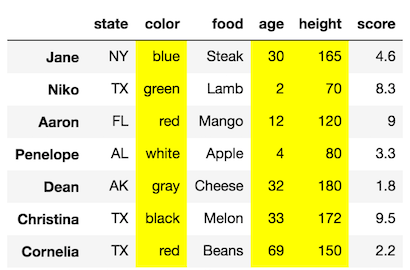

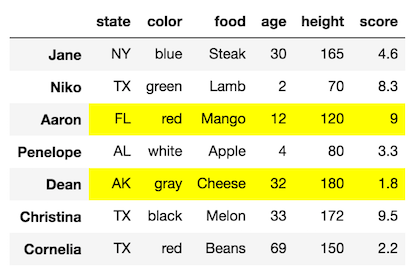

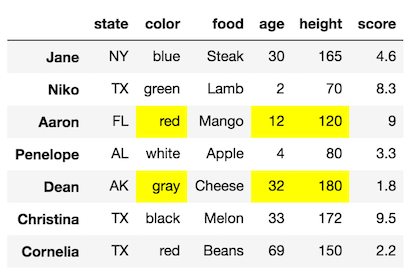

Homework 2:

In [82]:
df = pd.read_csv('task\\stackoverflow_qa.csv')
df.head()

,id,creationdate,score,viewcount,title,answercount,commentcount,favoritecount,quest_name,quest_rep,ans_name,ans_rep
0,332289,2008-12-01 21:24:44,3184,5962784,How do I change the size of figures drawn with...,14,1,0.0,tatwright,37837.0,NaN,NaN
1,2051744,2010-01-12 19:31:47,420,587728,How to invert the x or y axis,10,3,0.0,DarkAnt,4211.0,Demitri,13369.0
2,2225995,2010-02-09 00:51:38,51,59922,How can I create stacked line graph?,4,0,0.0,David Underhill,15936.0,doug,69290.0
3,5486226,2011-03-30 12:26:50,7,6393,Rolling median in python,5,4,0.0,yueerhu,175.0,Mike Pennington,42288.0
4,5515021,2011-04-01 14:50:44,10,13744,Compute a compounded return series in Python,3,6,0.0,Jason Strimpel,14916.0,Mike Pennington,42288.0


1. Find all questions that were created before 2014
2. Find all questions with a score more than 50
3. Find all questions with a score between 50 and 100
4. Find all questions answered by Scott Boston
5. Find all questions answered by the following 5 users
6. Find all questions that were created between March, 2014 and October 2014 that were answered by Unutbu and have score less than 5.
7. Find all questions that have score between 5 and 10 or have a view count of greater than 10,000
8. Find all questions that are not answered by Scott Boston

Homework 3:

Titanic data set, stored as CSV. The data consists of the following data columns:

- PassengerId: Id of every passenger.
- Survived: Indication whether passenger survived. 0 for yes and 1 for no.
- Pclass: One out of the 3 ticket classes: Class 1, Class 2 and Class 3.
- Name: Name of passenger.
- Sex: Gender of passenger.
- Age: Age of passenger in years.
- SibSp: Number of siblings or spouses aboard.
- Parch: Number of parents or children aboard.
- Ticket: Ticket number of passenger.
- Fare: Indicating the fare.
- Cabin: Cabin number of passenger.
- Embarked: Port of embarkation.

In [83]:
titanic_df = pd.read_csv("task\\titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. Select Female Passengers in Class 1 with Ages between 20 and 30:
Extract a DataFrame containing female passengers in Class 1 with ages between 20 and 30.

2. Filter Passengers Who Paid More than $100:
Create a DataFrame with passengers who paid a fare greater than $100.

3. Select Passengers Who Survived and Were Alone:
Filter passengers who survived and were traveling alone (no siblings, spouses, parents, or children).

4. Filter Passengers Embarked from 'C' and Paid More Than $50:
Create a DataFrame with passengers who embarked from 'C' and paid more than $50.

5. Select Passengers with Siblings or Spouses and Parents or Children:
Extract passengers who had both siblings or spouses aboard and parents or children aboard.

6. Filter Passengers Aged 15 or Younger Who Didn't Survive:
Create a DataFrame with passengers aged 15 or younger who did not survive.

7. Select Passengers with Cabins and Fare Greater Than $200:
Extract passengers with known cabin numbers and a fare greater than $200.

8. Filter Passengers with Odd-Numbered Passenger IDs:
Create a DataFrame with passengers whose PassengerId is an odd number.

9. Select Passengers with Unique Ticket Numbers:
Extract a DataFrame with passengers having unique ticket numbers.

10. Filter Passengers with 'Miss' in Their Name and Were in Class 1:
Create a DataFrame with female passengers having 'Miss' in their name and were in Class 1.

In [ ]:
import pandas as pd

df = pd.read_csv('task/titanic.csv')

# 1.
female_class1_20_30 = df[(df['Sex'] == 'female') & (df['Pclass'] == 1) & (df['Age'] >= 20) & (df['Age'] <= 30)]
print("Female Passengers in Class 1 with Ages between 20 and 30:")
print(female_class1_20_30)

# 2. 
paid_more_than_100 = df[df['Fare'] > 100]
print("\nPassengers Who Paid More than $100:")
print(paid_more_than_100)

# 3. 
survived_and_alone = df[(df['Survived'] == 1) & (df['SibSp'] == 0) & (df['Parch'] == 0)]
print("\nPassengers Who Survived and Were Alone:")
print(survived_and_alone)

# 4. 
embarked_C_paid_more_50 = df[(df['Embarked'] == 'C') & (df['Fare'] > 50)]
print("\nPassengers Embarked from 'C' and Paid More Than $50:")
print(embarked_C_paid_more_50)

# 5. 
siblings_spouses_and_parents_children = df[(df['SibSp'] > 0) & (df['Parch'] > 0)]
print("\nPassengers with Siblings or Spouses and Parents or Children:")
print(siblings_spouses_and_parents_children)

# 6. 
aged_15_or_younger_didnt_survive = df[(df['Age'] <= 15) & (df['Survived'] == 0)]
print("\nPassengers Aged 15 or Younger Who Didn't Survive:")
print(aged_15_or_younger_didnt_survive)

# 7. 
cabins_and_fare_greater_200 = df[(df['Cabin'].notnull()) & (df['Fare'] > 200)]
print("\nPassengers with Cabins and Fare Greater Than $200:")
print(cabins_and_fare_greater_200)

# 8. 
odd_numbered_passenger_ids = df[df['PassengerId'] % 2 != 0]
print("\nPassengers with Odd-Numbered Passenger IDs:")
print(odd_numbered_passenger_ids)

# 9. 
unique_tickets = df[df['Ticket'].duplicated(keep=False) == False]
print("\nPassengers with Unique Ticket Numbers:")
print(unique_tickets)

# 10. 
miss_in_name_class1 = df[(df['Name'].str.contains('Miss')) & (df['Pclass'] == 1)]
print("\nPassengers with 'Miss' in Their Name and Were in Class 1:")
print(miss_in_name_class1)